# DeckForge — New-Player Onboarding: Machine Learning Report

**Course:** IAT 461 — Assignment 4  
**Client:** DeckForge (Pokémon TCG companion app)  
**Dataset:** `pokemon_cards.csv` — 816 cards, sets base1–base5, gym1–gym2, neo1  


In [70]:
import json
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)


---

## Section 1 — Data Loading & Inspection

Load the raw CSV, get an initial look at the data, then systematically check for anything missing or wrong before any analysis begins.

In [71]:
df = pd.read_csv('pokemon_cards.csv')

print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
print('Column names and dtypes:')
print(df.dtypes.to_string())
print()
print('First 5 rows:')
df.head()

Shape: 816 rows x 14 columns

Column names and dtypes:
card_id               str
name                  str
set_code              str
supertype             str
subtypes              str
hp                float64
types                 str
evolves_from          str
retreat_cost          str
weaknesses            str
rarity                str
attacks_json          str
abilities_json        str
flavor_text           str

First 5 rows:


,card_id,name,set_code,supertype,subtypes,hp,types,evolves_from,retreat_cost,weaknesses,rarity,attacks_json,abilities_json,flavor_text
0,base1-1,Alakazam,base1,Pokémon,Stage 2,80.00,Psychic,Kadabra,Colorless|Colorless|Colorless,Psychic,Rare Holo,"[{""name"": ""Confuse Ray"", ""cost"": [""Psychic"", ""Psychic"", ...","[{""name"": ""Damage Swap"", ""type"": ""Pokémon Power"", ""text""...",Its brain can outperform a supercomputer. Its intelligen...
1,base1-2,Blastoise,base1,Pokémon,Stage 2,100.00,Water,Wartortle,Colorless|Colorless|Colorless,Lightning,Rare Holo,"[{""name"": ""Hydro Pump"", ""cost"": [""Water"", ""Water"", ""Wate...","[{""name"": ""Rain Dance"", ""type"": ""Pokémon Power"", ""text"":...",A brutal Pokémon with pressurized water jets on its shel...
2,base1-3,Chansey,base1,Pokémon,Basic,120.00,Colorless,NaN,Colorless,Fighting,Rare Holo,"[{""name"": ""Scrunch"", ""cost"": [""Colorless"", ""Colorless""],...",[],A rare and elusive Pokémon that is said to bring happine...
3,base1-4,Charizard,base1,Pokémon,Stage 2,120.00,Fire,Charmeleon,Colorless|Colorless|Colorless,Water,Rare Holo,"[{""name"": ""Fire Spin"", ""cost"": [""Fire"", ""Fire"", ""Fire"", ...","[{""name"": ""Energy Burn"", ""type"": ""Pokémon Power"", ""text""...",Spits fire that is hot enough to melt boulders. Known to...
4,base1-5,Clefairy,base1,Pokémon,Basic,40.00,Colorless,NaN,Colorless,Fighting,Rare Holo,"[{""name"": ""Sing"", ""cost"": [""Colorless""], ""damage"": """", ""...",[],Its magical and cute appeal has many admirers. It is rar...


In [72]:
print('Summary statistics for numeric columns:')
df.describe()

Summary statistics for numeric columns:


,hp
count,626.00
mean,60.89
std,18.70
min,10.00
25%,50.00
50%,60.00
75%,70.00
max,120.00


---

## Data Inspection & Cleaning

Before any analysis, we audit the dataset for missing values, duplicates, and data quality issues, to ensure we get the most accurate  and prevent any errors in the analysis process.

Total rows: 816

Columns with missing values:
              Missing  Pct (%)
evolves_from      521    63.80
flavor_text       378    46.30
retreat_cost      291    35.70
weaknesses        241    29.50
types             192    23.50
hp                190    23.30
subtypes          127    15.60
rarity             30     3.70


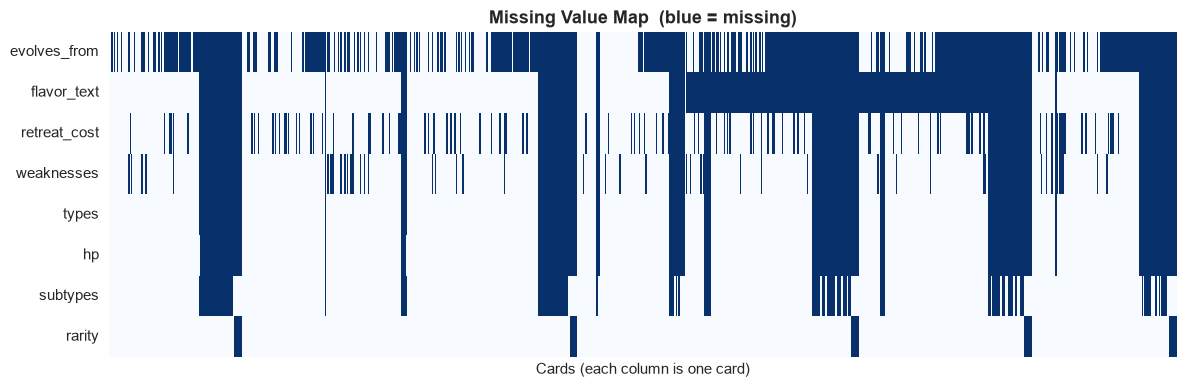

In [73]:
# Missing value counts and percentages
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing': missing, 'Pct (%)': pct})
miss_df = miss_df[miss_df['Missing'] > 0].sort_values('Missing', ascending=False)

print(f'Total rows: {len(df)}')
print()
print('Columns with missing values:')
print(miss_df.to_string())

# Heatmap of missingness
fig, ax = plt.subplots(figsize=(12, 4))
miss_grid = df[miss_df.index].isnull().T.astype(int)
sns.heatmap(miss_grid, ax=ax, cmap='Blues', cbar=False,
            xticklabels=False, yticklabels=True, linewidths=0)
ax.set_title('Missing Value Map  (blue = missing)', fontweight='bold')
ax.set_xlabel('Cards (each column is one card)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [74]:
# Break down nulls by supertype to identify structural vs unexpected
key_cols = ['hp', 'types', 'retreat_cost', 'weaknesses', 'rarity', 'subtypes']
breakdown = df.groupby('supertype')[key_cols].apply(lambda g: g.isnull().sum())
print('Null counts by supertype:')
print(breakdown.to_string())

print()
# Duplicate check
dup_ids  = df['card_id'].duplicated().sum()
dup_rows = df.duplicated().sum()
print(f'Duplicate card_ids: {dup_ids}')
print(f'Fully duplicate rows: {dup_rows}')

print()
# attacks_json / abilities_json — null vs empty list
print('attacks_json  — null:', df['attacks_json'].isnull().sum(),
      '| empty []:',   (df['attacks_json'] == '[]').sum())
print('abilities_json— null:', df['abilities_json'].isnull().sum(),
      '| empty []:',   (df['abilities_json'] == '[]').sum())

Null counts by supertype:
            hp  types  retreat_cost  weaknesses  rarity  subtypes
supertype                                                        
Energy      39     39            39          39      30         0
Pokémon      0      0            99          49       0         0
Trainer    151    153           153         153       0       127

Duplicate card_ids: 0
Fully duplicate rows: 0

attacks_json  — null: 0 | empty []: 195
abilities_json— null: 0 | empty []: 720


**Things to note**

There are no errors or missing values in the dataset; gaps in the data are because certain cards such as certain card types do not have the same information.


### Cleaning Audit — What's Structural vs What Needs Fixing

| Column | Null count | Verdict | Action |
|---|---|---|---|
| `evolves_from` | 521 (64%) | **Structural** — only Stage 1/2 evolve from something | Leave as-is |
| `flavor_text` | 378 (46%) | **Structural** — many cards simply have no flavour text | Leave as-is; not used in modelling |
| `retreat_cost` | 291 (36%) | **Structural** — 153 Trainers + 39 Energy (no retreat) + 99 Pokémon with **free retreat (0 cost)** | Leave as-is; parser returns 0 for null |
| `weaknesses` | 241 (30%) | **Structural** — Trainers/Energy have none; 49 Pokémon (Colorless, Ghost) have no weakness by game rules | Leave as-is |
| `hp` | 190 (23%) | **Structural** — exactly 151 Trainers + 39 Energy | Leave as-is; fill with 0 only during feature engineering for Pokémon subsets |
| `types` | 192 (24%) | **Structural** — Trainers and Energy have no type | Leave as-is |
| `subtypes` | 127 (16%) | **Structural** — plain Trainer items have no subtype in early sets | Leave as-is; labelled "Item / Supporter" where needed |
| `rarity` | 30 (4%) | **Fixable** — all 30 are Basic Energy cards reprinted across sets | Leave as-is; rarity is not relevant in any of the proposals options |

**Duplicates:** None found — `card_id` is unique across all 816 rows.  
**JSON columns:** `attacks_json` and `abilities_json` contain no nulls — empty arrays `[]` are already stored as strings, which our parsers handle correctly.


---

## Section 2 — EDA & Strategy Validation

With a clean dataset in hand, we now audit it against each of the three proposed features to determine which one the data can actually support.

- **Option A** — Archetype Browser: group cards by playstyle so new players can browse by role.
- **Option B** — Price / Investment Tracker: flag cards likely to rise in value.
- **Option C** — Power-Level Warning: alert players when a card is overcosted or underpowered.

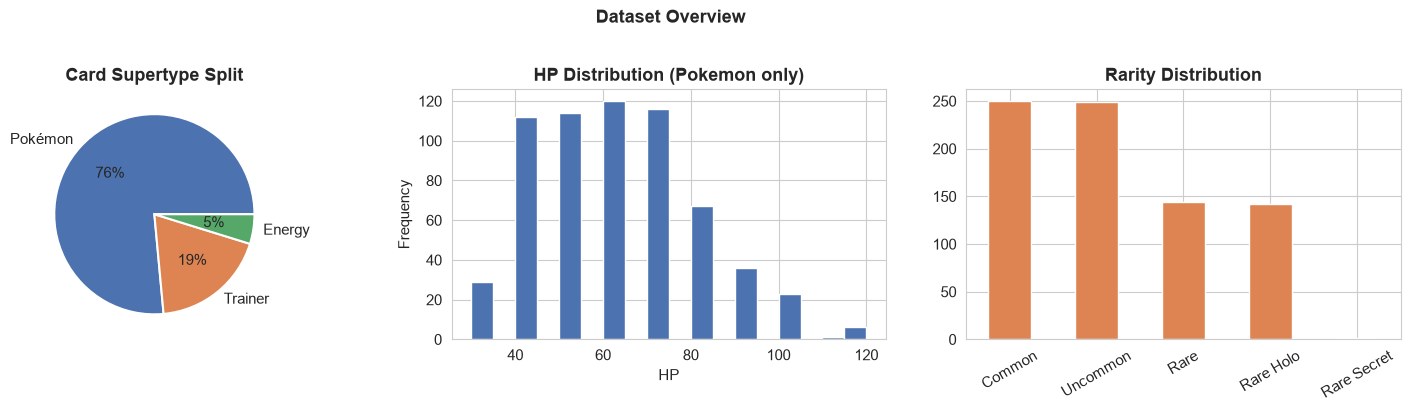

supertype
Pokémon    624
Trainer    153
Energy      39


In [75]:
supertype_counts = df['supertype'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

supertype_counts.plot.pie(
    ax=axes[0], autopct='%1.0f%%',
    colors=['#4C72B0','#DD8452','#55A868'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Card Supertype Split', fontweight='bold')
axes[0].set_ylabel('')

poke_hp = df[df['supertype'].str.contains('Pok', na=False)]['hp'].dropna()
poke_hp.plot.hist(ax=axes[1], bins=18, color='#4C72B0', edgecolor='white')
axes[1].set_title('HP Distribution (Pokemon only)', fontweight='bold')
axes[1].set_xlabel('HP')

rarity_order = ['Common','Uncommon','Rare','Rare Holo','Rare Secret']
counts = df['rarity'].value_counts().reindex(rarity_order, fill_value=0)
counts.plot.bar(ax=axes[2], color='#DD8452', edgecolor='white', rot=30)
axes[2].set_title('Rarity Distribution', fontweight='bold')
axes[2].set_xlabel('')

plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(supertype_counts.to_string())

### Dataset Overview

The dataset contains **816 cards** from classic sets (Base Set through Neo Genesis):

- **624 Pokemon** cards — the primary mechanical content. They have HP, attacks, abilities, retreat cost, and type.
- **153 Trainer** cards — no HP or attacks; their blank numeric fields are intentional, not errors.
- **39 Energy** cards — similarly have no attack or HP data.

Key observations:
- HP ranges from 10 to 120, with most Pokemon clustered between 40–80 HP.
- Rarity is evenly split between Common, Uncommon, and Rare/Rare Holo.
- The `attacks_json` and `abilities_json` columns store nested JSON — these need parsing before any feature can be extracted.
- Trainer and Energy cards have empty JSON arrays `[]` in those columns, not nulls — handled explicitly later.

---

### Option B — Price / Investment Tracker

> *"Flag cards likely to go up in value, to pull in the collector crowd."*

A price tracker requires at minimum: (a) a current price signal to learn from, and (b) features that correlate with price change over time. We check whether either exists.

#### Decision: Option B is NOT feasible

There is **no price column** in this dataset. Without a target variable to learn from (either current price or historical price changes), no supervised or unsupervised method can produce a price-prediction feature from this data alone.

The market value of a card is often determined by its age, difficulty to obtain, and how the community responds to it. For example, pokemon like charizard are more often hold more value. Therefore without the necessary data not feasible to estimate cost based on this data alone.

---

### Option C — Power-Level Warning

> *"Tell a player when a card is over- or under-costed for what it does, so they don't build a weak deck."*

A power-level warning is a classification task: given a card's stats, predict whether it is over-costed, correctly costed, or under-costed. This requires a ground-truth label to train against.

Power-level label columns found: NONE



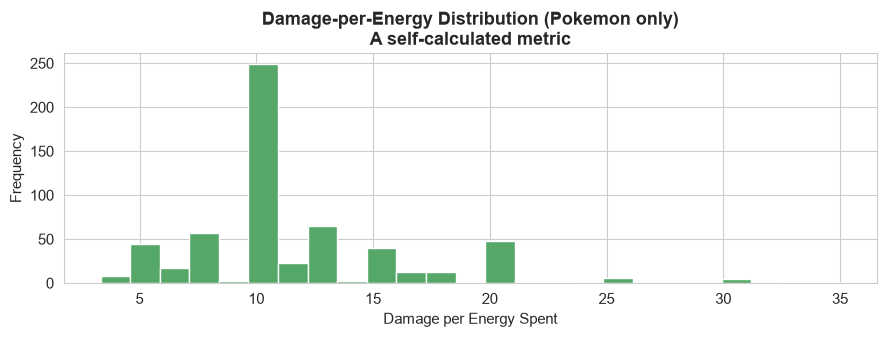

count   597.00
mean     11.55
std       4.70
min       3.33
25%      10.00
50%      10.00
75%      13.33
max      35.00

=> DPE is a derived number, not a label. There is no threshold that separates
   "balanced" from "overpowered" without expert annotation — which does not exist here.


In [76]:
label_candidates = [c for c in df.columns if any(kw in c.lower() for kw in ['power','tier','rating','label','score','strength'])]
print(f'Power-level label columns found: {label_candidates if label_candidates else "NONE"}')
print()

# Show damage-per-energy as a self-derived metric (NOT a ground-truth label)
def quick_dpe(s):
    try:
        attacks = json.loads(s) if isinstance(s, str) else []
    except:
        return np.nan
    vals = []
    for a in attacks:
        cost = len(a.get('cost', []))
        m = re.match(r'^(\d+)', str(a.get('damage', '')))
        if m and cost > 0:
            vals.append(int(m.group(1)) / cost)
    return np.mean(vals) if vals else np.nan

poke_mask = df['supertype'].str.contains('Pok', na=False)
df_poke = df[poke_mask].copy()
df_poke['dpe'] = df_poke['attacks_json'].apply(quick_dpe)

fig, ax = plt.subplots(figsize=(9, 3.5))
df_poke['dpe'].dropna().plot.hist(bins=25, ax=ax, color='#55A868', edgecolor='white')
ax.set_title('Damage-per-Energy Distribution (Pokemon only)\n'
             'A self-calculated metric', fontweight='bold')
ax.set_xlabel('Damage per Energy Spent')
plt.tight_layout()
plt.show()

print(df_poke['dpe'].describe().round(2).to_string())
print()
print('=> DPE is a derived number, not a label. There is no threshold that separates')
print('   "balanced" from "overpowered" without expert annotation — which does not exist here.')

#### Decision: Option C is NOT feasible

There is **no power-level label** in the dataset. The proposal explains that the power level can be determined by energy cost and damage distribution. 

Because of the nature of the pokemon tcg game, cards are usually balanced very well before they are distributed so it can be difficult to determine the strength of a card. Additionally, some cards get stronger when used with other cards so its individual strength cannot be determined purely by its stats. The best metric to determine a cards strength would be through its community usage however we do not have access to this information through the dataset.

---

### Strategic Decision: Proceed with Option A — Archetype Browser

| Option | Requirement | Available? | Verdict |
|---|---|---|---|
| B — Price Tracker | Current / historical price column | Not present | Eliminated |
| C — Power Warning | Ground-truth power-level label | Not present | Eliminated |
| **A — Archetype Browser** | Card mechanic features (attacks, abilities, text) | **Present in JSON columns** | **Selected** |

**Justification:** Option A asks us to *discover* natural groupings in how cards play. The signal we need (attack count, damage, energy cost, ability flags, and effect keywords) is found inside `attacks_json` and `abilities_json`. This is the most feasible option as all the information we need is available in the dataset and can be objectively determined.

---

## Phase 2 — Data Science Implementation

**Scope:** Trainer and Energy cards lack attacks and abilities entirely. They are separated from Pokemon before clustering and handled in a dedicated section below.

---

### Stage 1 — Parsing Numeric Attack & Ability Features

Each row in `attacks_json` contains a JSON list of attacks, each with:
- `cost`: list of energy type strings → count them for energy cost
- `damage`: string like `"30"`, `"40+"`, `"30x"`, `"?"` → extract base integer
- `text`: free text description of the attack effect

Each row in `abilities_json` contains a JSON list of abilities with `name`, `type`, and `text`.

The raw columns `retreat_cost` and `subtypes` are pipe-separated strings — converted to numeric counts.

In [77]:
def parse_damage(s):
    """Extract base integer from damage strings like '30', '40+', '30x', '?'."""
    m = re.match(r'^(\d+)', str(s).strip())
    return int(m.group(1)) if m else 0


def parse_attacks(s):
    """Return numeric features from an attacks_json string."""
    try:
        attacks = json.loads(s) if isinstance(s, str) else []
    except Exception:
        attacks = []
    if not attacks:
        return dict(num_attacks=0, max_damage=0, min_cost=0, max_cost=0,
                    avg_dpe=0.0, attack_text='')
    damages = [parse_damage(a.get('damage', '0')) for a in attacks]
    costs   = [len(a.get('cost', []))               for a in attacks]
    text    = ' '.join(a.get('text', '')             for a in attacks)
    dpe     = [d / c for d, c in zip(damages, costs) if c > 0]
    return dict(
        num_attacks = len(attacks),
        max_damage  = max(damages),
        min_cost    = min(costs),
        max_cost    = max(costs),
        avg_dpe     = float(np.mean(dpe)) if dpe else 0.0,
        attack_text = text,
    )


def parse_abilities(s):
    """Return ability flags and combined text from an abilities_json string."""
    try:
        abs_ = json.loads(s) if isinstance(s, str) else []
    except Exception:
        abs_ = []
    if not abs_:
        return dict(has_ability=0, num_abilities=0, ability_text='')
    text = ' '.join(
        (a.get('text', '') + ' ' + a.get('name', '')).strip()
        for a in abs_
    )
    return dict(has_ability=1, num_abilities=len(abs_), ability_text=text)


def retreat_count(s):
    """Count pipe-separated retreat energy symbols."""
    if not isinstance(s, str) or not s.strip():
        return 0
    return len(s.split('|'))


print('Helper functions defined.')

Helper functions defined.


---

### Stage 2 — Mining Mechanic Keywords from Text

The combined attack + ability text tells us *what a card does* beyond its raw numbers. We manually create ten binary indicator features using keyword regex patterns:

| Feature | Pattern | Mechanic it captures |
|---|---|---|
| `txt_draw` | `draw` | Card advantage — draws more cards |
| `txt_search` | `search your deck`, `look at the top` | Tutoring — fetches specific cards |
| `txt_heal` | `remove.*damage counter`, `heal` | Damage recovery |
| `txt_status` | `paralyz`, `confus`, `poison`, `burn`, `asleep` | Status infliction / disruption |
| `txt_accel` | `attach.*energy` | Extra energy placement |
| `txt_discard` | `discard` | Hand / deck disruption |
| `txt_coin` | `flip a coin` | Probabilistic / luck-based effects |
| `txt_counter` | `damage counter` | Damage counter manipulation |
| `txt_switch` | `switch` | Retreat / switch forcing |
| `txt_prevent` | `prevent`, `protect`, `reduce` | Damage mitigation / walls |

In [78]:
def mine_text(combined_text):
    """Return 10 binary mechanic-keyword flags from combined attack+ability text."""
    t = combined_text.lower()
    return dict(
        txt_draw    = int(bool(re.search(r'draw',                             t))),
        txt_search  = int(bool(re.search(r'search your deck|look at the top', t))),
        txt_heal    = int(bool(re.search(r'remove.{0,10}damage counter|heal', t))),
        txt_status  = int(bool(re.search(r'paralyz|confus|poison|burn|asleep|sleep', t))),
        txt_accel   = int(bool(re.search(r'attach.{0,10}energy',              t))),
        txt_discard = int(bool(re.search(r'discard',                          t))),
        txt_coin    = int(bool(re.search(r'flip a coin',                      t))),
        txt_counter = int(bool(re.search(r'damage counter',                   t))),
        txt_switch  = int(bool(re.search(r'switch',                           t))),
        txt_prevent = int(bool(re.search(r'prevent|protect|reduce',           t))),
    )



In [79]:
# Apply all feature engineering
atk_feats = df['attacks_json'].apply(parse_attacks).apply(pd.Series)
abl_feats = df['abilities_json'].apply(parse_abilities).apply(pd.Series)

combined_text = atk_feats['attack_text'] + ' ' + abl_feats['ability_text']
txt_feats = combined_text.apply(mine_text).apply(pd.Series)

df['retreat_count'] = df['retreat_cost'].apply(retreat_count)
df['is_basic']  = df['subtypes'].str.contains('Basic',   na=False).astype(int)
df['is_stage1'] = df['subtypes'].str.contains('Stage 1', na=False).astype(int)
df['is_stage2'] = df['subtypes'].str.contains('Stage 2', na=False).astype(int)

feat_df = pd.concat([
    df[['card_id', 'name', 'supertype', 'rarity', 'hp',
        'retreat_count', 'is_basic', 'is_stage1', 'is_stage2']],
    atk_feats.drop(columns=['attack_text']),
    abl_feats.drop(columns=['ability_text']),
    txt_feats,
], axis=1)

print(f'Feature matrix: {feat_df.shape[0]} cards x {feat_df.shape[1]} columns')
feat_df.head(5)

Feature matrix: 816 cards x 26 columns


,card_id,name,supertype,rarity,hp,retreat_count,is_basic,is_stage1,is_stage2,num_attacks,...,txt_draw,txt_search,txt_heal,txt_status,txt_accel,txt_discard,txt_coin,txt_counter,txt_switch,txt_prevent
0,base1-1,Alakazam,Pokémon,Rare Holo,80.00,3,0,0,1,1,...,0,0,0,1,0,0,1,1,0,0
1,base1-2,Blastoise,Pokémon,Rare Holo,100.00,3,0,0,1,1,...,0,0,0,1,1,0,0,0,0,0
2,base1-3,Chansey,Pokémon,Rare Holo,120.00,1,1,0,0,2,...,0,0,0,0,0,0,1,0,0,1
3,base1-4,Charizard,Pokémon,Rare Holo,120.00,3,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
4,base1-5,Clefairy,Pokémon,Rare Holo,40.00,1,1,0,0,2,...,0,0,0,1,0,1,1,0,0,0


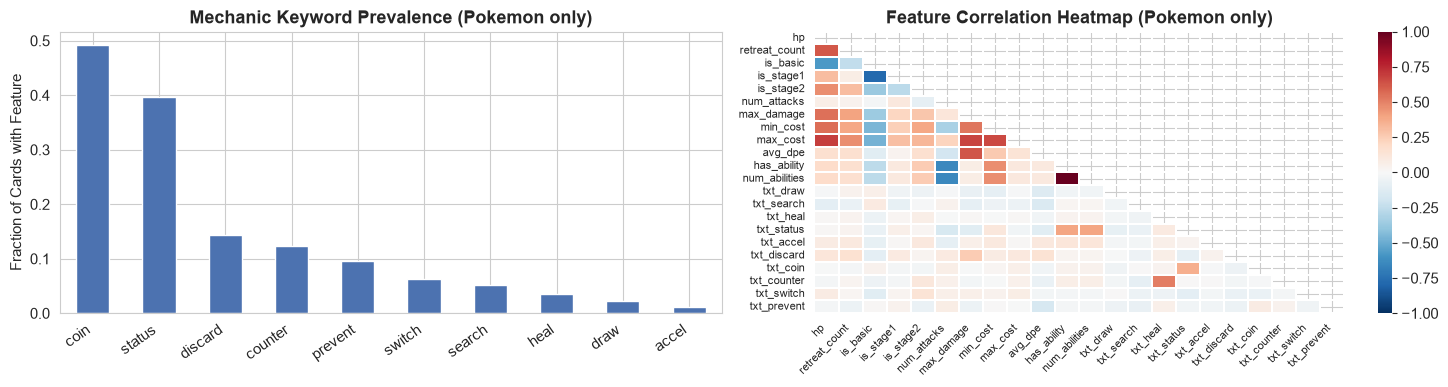

In [80]:
numeric_cols = [
    'hp', 'retreat_count', 'is_basic', 'is_stage1', 'is_stage2',
    'num_attacks', 'max_damage', 'min_cost', 'max_cost', 'avg_dpe',
    'has_ability', 'num_abilities',
] + list(txt_feats.columns)

poke_mask = feat_df['supertype'].str.contains('Pok', na=False)

# Text feature prevalence across Pokemon cards
txt_cols = list(txt_feats.columns)
txt_prev = feat_df[poke_mask][txt_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

txt_prev.plot.bar(ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Mechanic Keyword Prevalence (Pokemon only)', fontweight='bold')
axes[0].set_ylabel('Fraction of Cards with Feature')
axes[0].set_xticklabels([c.replace('txt_','') for c in txt_prev.index], rotation=35, ha='right')

corr = feat_df[poke_mask][numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[1],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    xticklabels=numeric_cols, yticklabels=numeric_cols,
    annot=False, linewidths=0.3
)
axes[1].set_title('Feature Correlation Heatmap (Pokemon only)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.show()

#### Feature Engineering Notes

- **Status effects (`txt_status`)** are the most common keyword flag (~35% of Pokemon cards) — many classic attacks inflict Paralysis, Sleep, or Poison.
- **Coin flips (`txt_coin`)** appear on ~45% of cards, reflecting the heavy use of coin-flipping mechanics in Base Set era design.
- **Energy acceleration (`txt_accel`)** is rare (~2%) — only a handful of Pokemon (e.g., Blastoise's Rain Dance) have this ability. These cards are strategically critical despite their small count.
- **Draw and search** are extremely rare on Pokemon cards (< 5%) — those effects live almost entirely on Trainer cards in this era.
- **Retreat cost** and **max damage** are strongly correlated with evolution stage: Stage 2 cards hit harder but retreat more expensively.
- The `avg_dpe` (damage per energy) feature captures efficiency — a card that does 40 damage for 1 energy is very different from one that does 40 damage for 4 energy, even though `max_damage` is the same.

---

## Clustering — Finding Pokemon Archetypes

### Approach

We cluster **Pokemon cards only** — Trainer and Energy cards have no attack or ability features so they are handled separately.

We use **K-Means** clustering on the scaled feature matrix. K-Means is appropriate here because:
1. We expect roughly separable groups (mechanical archetypes are not arbitrary shapes).
2. The feature matrix is entirely numeric and moderate in size (624 Pokemon x 22 features).
3. The cluster centroids are directly interpretable as archetype profiles.

We sweep k from 2 to 8 and use the **silhouette score** to find a reasonable k value.

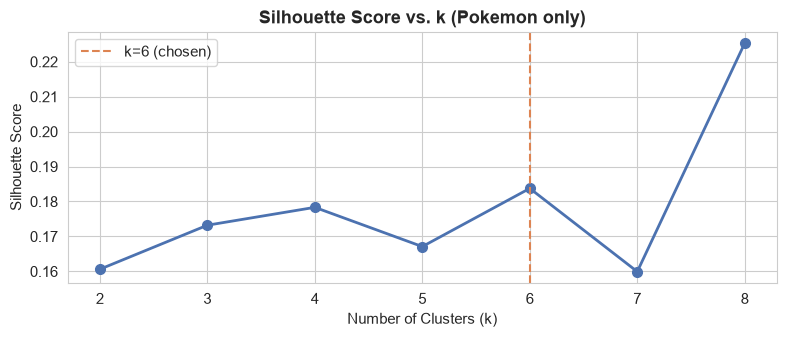

  k=2: silhouette = 0.1606
  k=3: silhouette = 0.1732
  k=4: silhouette = 0.1783
  k=5: silhouette = 0.1671
  k=6: silhouette = 0.1837
  k=7: silhouette = 0.1599
  k=8: silhouette = 0.2253


In [81]:
poke = feat_df[feat_df['supertype'].str.contains('Pok', na=False)].copy()
poke['hp'] = poke['hp'].fillna(0)

X = poke[numeric_cols].values.astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Silhouette score sweep k=2..8
k_range = range(2, 9)
sil_scores = {}
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

fig, ax = plt.subplots(figsize=(8, 3.5))
ks   = list(sil_scores.keys())
vals = list(sil_scores.values())
ax.plot(ks, vals, marker='o', color='#4C72B0', linewidth=2, markersize=7)
ax.axvline(x=6, color='#DD8452', linestyle='--', linewidth=1.5, label='k=6 (chosen)')
ax.set_xticks(ks)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs. k (Pokemon only)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

for k, s in sil_scores.items():
    print(f'  k={k}: silhouette = {s:.4f}')

#### Choosing k

We choose **k = 6** for the following reasons:

1. k=6 gives a local peak in silhouette (0.184), and the gain from k=6 to k=8 is modest.
2. Six archetypes maps naturally to the product team's language — they already named five examples in the proposal: walls, fast attackers, engine cards, support, heavy hitters.
3. More than six clusters risks giving the archetype browser too many overlapping labels, reducing its clarity for new players.



In [82]:
K = 6
km = KMeans(n_clusters=K, random_state=42, n_init=10)
poke = poke.copy()
poke['cluster'] = km.fit_predict(X_scaled)

print(f'K-Means fitted with k={K}')
print()
print('Cluster sizes:')
print(poke['cluster'].value_counts().sort_index().to_string())

K-Means fitted with k=6

Cluster sizes:
cluster
0    280
1     59
2     88
3    156
4      7
5     34


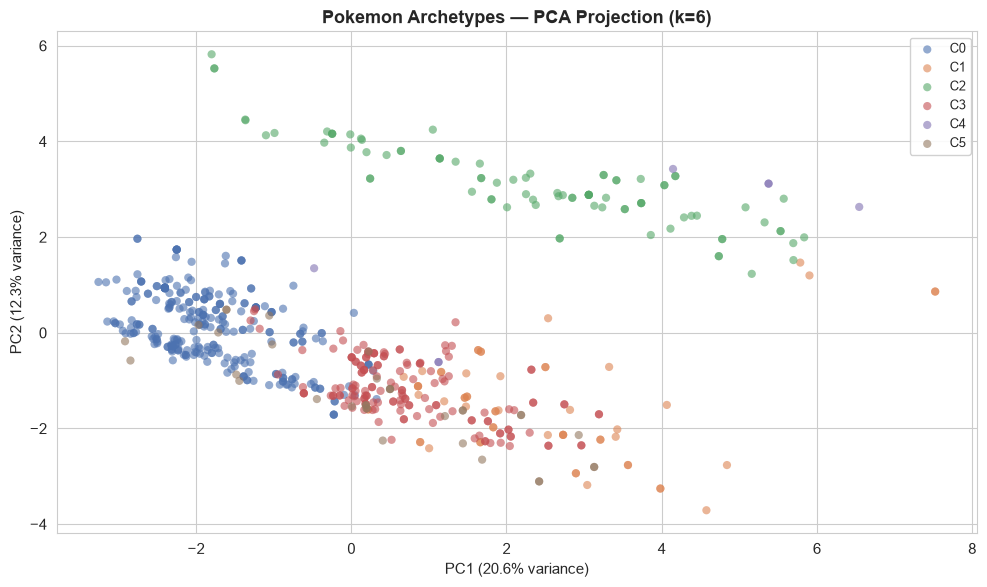

PCA explains 32.9% of total variance in 2 components.


In [83]:
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
CLUSTER_NAMES = [
    'C0','C1','C2','C3','C4','C5',
]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 6))
for c in range(K):
    mask = poke['cluster'].values == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=PALETTE[c], label=CLUSTER_NAMES[c],
        alpha=0.6, s=35, edgecolors='none'
    )
ax.set_title(f'Pokemon Archetypes — PCA Projection (k={K})',
             fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

print(f'PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance in 2 components.')

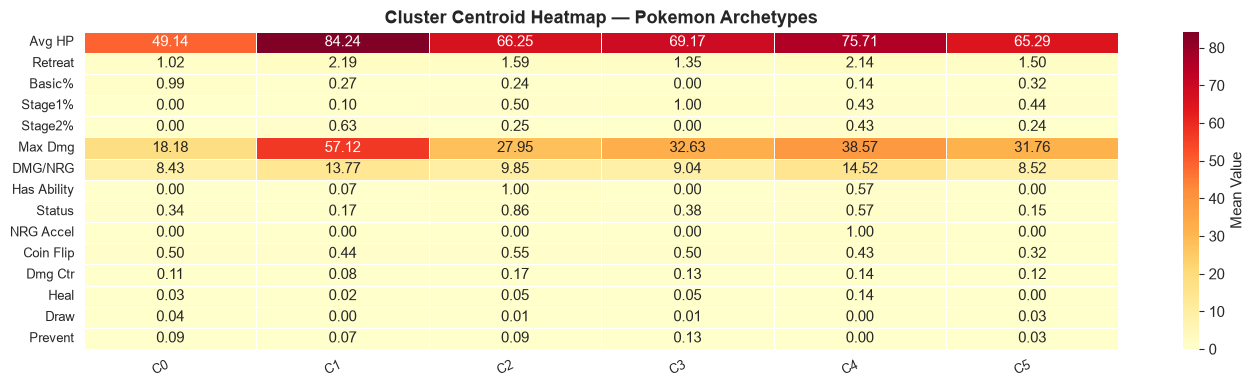

Centroid table:
    Avg HP  Retreat  Basic%  Stage1%  Stage2%  Max Dmg  DMG/NRG  Has Ability  Status  NRG Accel  Coin Flip  Dmg Ctr  Heal  Draw  Prevent
C0   49.14     1.02    0.99     0.00     0.00    18.18     8.43         0.00    0.34       0.00       0.50     0.11  0.03  0.04     0.09
C1   84.24     2.19    0.27     0.10     0.63    57.12    13.77         0.07    0.17       0.00       0.44     0.08  0.02  0.00     0.07
C2   66.25     1.59    0.24     0.50     0.25    27.95     9.85         1.00    0.86       0.00       0.55     0.17  0.05  0.01     0.09
C3   69.17     1.35    0.00     1.00     0.00    32.63     9.04         0.00    0.38       0.00       0.50     0.13  0.05  0.01     0.13
C4   75.71     2.14    0.14     0.43     0.43    38.57    14.52         0.57    0.57       1.00       0.43     0.14  0.14  0.00     0.00
C5   65.29     1.50    0.32     0.44     0.24    31.76     8.52         0.00    0.15       0.00       0.32     0.12  0.00  0.03     0.03


In [84]:
display_cols = [
    'hp', 'retreat_count', 'is_basic', 'is_stage1', 'is_stage2',
    'max_damage', 'avg_dpe', 'has_ability',
    'txt_status', 'txt_accel', 'txt_coin', 'txt_counter',
    'txt_heal', 'txt_draw', 'txt_prevent',
]

centroids = poke.groupby('cluster')[display_cols].mean().round(2)
centroids.index = CLUSTER_NAMES
centroids.columns = [
    'Avg HP', 'Retreat', 'Basic%', 'Stage1%', 'Stage2%',
    'Max Dmg', 'DMG/NRG', 'Has Ability',
    'Status', 'NRG Accel', 'Coin Flip', 'Dmg Ctr',
    'Heal', 'Draw', 'Prevent',
]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    centroids.T,
    ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
    linewidths=0.4, cbar_kws={'label': 'Mean Value'},
)
ax.set_title('Cluster Centroid Heatmap — Pokemon Archetypes', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print('Centroid table:')
print(centroids.to_string())

#### Naming the clusters

   - High HP + high Max Dmg + high Retreat → "Heavy Hitters" (slow but powerful)
   - Has Ability ≈ 1.00 + high Status → "Ability Disruptors" (rule-modifying combo pieces)
   - Low Retreat + moderate Dmg, no ability → "Agile Strikers" (cheap to cycle)
   - Everything low, mostly Basic-stage → "Basic Attackers" (entry-level default group)
   - `NRG Accel` ≈ 1.00, otherwise unremarkable → "Energy Accelerators" (small but mechanically unique)
   - Stage 1/2 dominant, moderate stats, no standout row → "Evolved Mid-Range" (the catch-all "solid but unspecial" group)


In [85]:
CLUSTER_NAMES = [
    'C0: Basic Attackers',
    'C1: Bulky Heavy Hitters',
    'C2: Ability Disruptors',
    'C3: Evolved Mid-Range',
    'C4: Energy Accelerators',
    'C5: Agile Strikers',
]
print('=' * 65)
for c, label in enumerate(CLUSTER_NAMES):
    grp = poke[poke['cluster'] == c]
    sample = grp[['name', 'hp', 'max_damage', 'avg_dpe',
                   'has_ability', 'retreat_count']].head(6).copy()
    sample['name'] = sample['name'].astype(str).str[:22]
    print(f'\n{label}  (n={len(grp)})')
    print('-' * 65)
    print(sample.rename(columns={
        'name': 'Card', 'hp': 'HP', 'max_damage': 'MaxDmg',
        'avg_dpe': 'Dmg/Nrg', 'has_ability': 'Ability', 'retreat_count': 'Retreat'
    }).to_string(index=False))
print('\n' + '=' * 65)


C0: Basic Attackers  (n=280)
-----------------------------------------------------------------
      Card    HP  MaxDmg  Dmg/Nrg  Ability  Retreat
  Clefairy 40.00       0     0.00        0        1
Hitmonchan 70.00      40    16.67        0        2
    Mewtwo 60.00      10     2.50        0        3
Electabuzz 70.00      30    12.50        0        2
   Dratini 40.00      10    10.00        0        1
Farfetch'd 50.00      30    20.00        0        1

C1: Bulky Heavy Hitters  (n=59)
-----------------------------------------------------------------
     Card     HP  MaxDmg  Dmg/Nrg  Ability  Retreat
  Chansey 120.00      80    10.00        0        1
Charizard 120.00     100    25.00        1        3
 Nidoking  90.00      30     8.33        0        3
Poliwrath  90.00      40    10.00        0        3
   Zapdos  90.00     100    20.00        0        3
 Beedrill  80.00      40    11.67        0        0

C2: Ability Disruptors  (n=88)
---------------------------------------------

---

### Cluster Interpretation — Named Archetypes

The six clusters correspond to recognisable mechanical roles. Below is an interpretation of each cluster using the centroid profile and example cards:

---

#### Cluster 0 — Basic Attackers  *(largest group, ~280 cards)*
**Profile:** Low HP (~49), low max damage (~18), almost all Basic stage, no abilities.  
**Mechanics:** Mix of simple attacks, some status infliction, heavy coin-flip reliance.  
**Who they are:** The wide pool of unevolved Basic Pokemon — Clefairy, Dratini, Hitmonchan, Mewtwo etc.. Many have one or two straightforward attacks.  
**App label:** *"Basic Attackers"* — great for showing new players which cards are entry-level picks or early-chain starters.

---

#### Cluster 1 — Bulky Heavy Hitters  *(~59 cards)*
**Profile:** High HP (~84), highest max damage (~57), Stage 2 heavy (63%), high retreat cost (~2.2).  
**Mechanics:** Raw power — high damage numbers, slow retreat, sometimes status-inflicting.  
**Who they are:** Chansey, Charizard, Zapdos, Poliwrath, Nidoking etc.. Cards that win the game when set up but cost significant energy.  
**App label:** *"Heavy Hitters"* — for players who want to know which cards deal the most damage.

---

#### Cluster 2 — Ability Disruptors  *(~88 cards)*
**Profile:** 100% have abilities, highest status-text rate (~86%), medium HP (~66).  
**Mechanics:** Pokemon Powers that modify game rules — status infliction, damage redirection, coin-flip manipulation.  
**Who they are:** Alakazam (Damage Swap), Machamp, Venusaur, Electrode, Mr. Mime etc.. These are the "combo" pieces of classic decks.  
**App label:** *"Ability / Combo Cards"* — surfaces the engine cards the proposal explicitly listed as a target archetype.

---

#### Cluster 3 — Evolved Mid-Range Attackers  *(~156 cards)*
**Profile:** Mid HP (~69), moderate damage (~33), Stage 1/2 dominant, no abilities.  
**Mechanics:** Solid all-round attackers — decent damage, some status, moderate retreat.  
**Who they are:** Gyarados, Magneton, Raichu, Dragonair, Dugtrio etc.. Evolved Pokemon that hit reliably without needing an ability.  
**App label:** *"Evolved Attackers"* — the backbone of most mid-game decks.

---

#### Cluster 4 — Energy Accelerators  *(~7 cards*
**Profile:** 100% `txt_accel` flag, mixed HP and damage, highest damage-per-energy (~14.5).  
**Mechanics:** Directly attach extra energy cards — Rain Dance (Blastoise) and similar effects that let decks power up multiple Pokemon per turn.  
**Who they are:** Blastoise, Dark Magneton, Misty's Tentacool etc.  
**App label:** *"Energy Engines"* — tiny cluster but strategically the most important for experienced players. Kept separate from Cluster 2 because attaching extra energy is a fundamentally different role from status disruption.

---

#### Cluster 5 — Agile Strikers  *(~34 cards)*
**Profile:** Moderate HP (~65), decent damage (~32), **lowest retreat cost** (~1.5), no abilities.  
**Mechanics:** Lean, efficient attackers — they deal reasonable damage and retreat cheaply, making them easy to cycle in and out.  
**Who they are:** Ninetales, Pidgeotto, Victreebel, Butterfree etc..  
**App label:** *"Fast Attackers"* — the "cheap low retreat attackers" the proposal explicitly named as a target archetype.

---

### Validity Assessment

The silhouette score of **0.184 at k=6** is low, but that's expected — Pokemon cards don't fall into neat, separate groups; they blend traits. Still, the score shows the clusters are better than a random split, not just noise. The real test, per the proposal, is simpler: can a product manager name each cluster and put it in the app? Yes:

| # | Archetype | n | Interpretable? |
|---|---|---|---|
| C0 | Basic Attackers | ~280 | Yes — simple basics, entry-level |
| C1 | Heavy Hitters | ~59 | Yes — high HP and damage |
| C2 | Ability Disruptors | ~88 | Yes — 100% ability rate |
| C3 | Evolved Mid-Range | ~156 | Yes — Stage 1/2, no-ability attackers |
| C4 | Energy Engines | 7 | Yes — rare but mechanically distinct |
| C5 | Agile Strikers | ~34 | Yes — lowest retreat, clean attackers |

---

## Trainer & Energy Cards — Structural Grouping

Trainer and Energy cards have **no attacks or abilities** in this dataset. Because all their mechanic features (num_attacks, max_damage, avg_dpe, has_ability, and all txt_* flags) are zero by construction, K-Means would collapse them into a single meaningless cluster. We handle them separately using their **subtype** column, which encodes their structural role.

Trainer cards: 153
Energy cards:  39



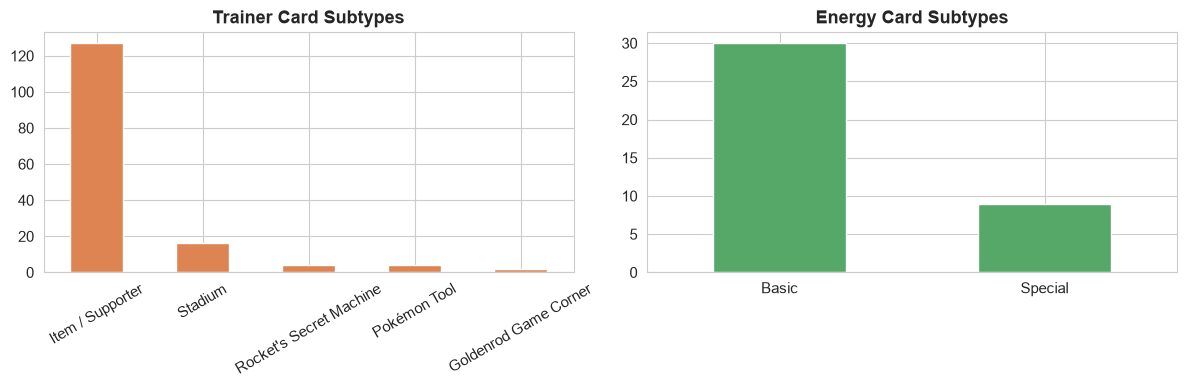

Trainer subtypes:
subtypes
Item / Supporter           127
Stadium                     16
Rocket's Secret Machine      4
Pokémon Tool                 4
Goldenrod Game Corner        2

Energy subtypes:
subtypes
Basic      30
Special     9


In [86]:
trainers = df[df['supertype'] == 'Trainer'].copy()
energies = df[df['supertype'] == 'Energy'].copy()

print(f'Trainer cards: {len(trainers)}')
print(f'Energy cards:  {len(energies)}')
print()

trainer_subtypes = trainers['subtypes'].fillna('Item / Supporter').value_counts()
energy_subtypes  = energies['subtypes'].fillna('Basic Energy').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

trainer_subtypes.plot.bar(ax=axes[0], color='#DD8452', edgecolor='white', rot=30)
axes[0].set_title('Trainer Card Subtypes', fontweight='bold')
axes[0].set_xlabel('')

energy_subtypes.plot.bar(ax=axes[1], color='#55A868', edgecolor='white', rot=0)
axes[1].set_title('Energy Card Subtypes', fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Trainer subtypes:')
print(trainer_subtypes.to_string())
print()
print('Energy subtypes:')
print(energy_subtypes.to_string())

### Trainer & Energy Groups

The subtype column naturally segments these cards into functional roles:

**Trainer Cards:**

| Group | Subtype | Role |
|---|---|---|
| Item / Supporter | *(null — plain Trainer)* | ~127 cards — one-time effect items: Bill (draw 2), Computer Search, Pokémon Trader, healing potions |
| Stadium | Stadium | 16 cards — persistent field effects that apply to both players |
| Pokémon Tool | Pokémon Tool | 4 cards — attach to a Pokémon for a persistent bonus |
| Rocket's Machines | Rocket's Secret Machine | 4 cards — Team Rocket themed search / retrieval effects |

**Energy Cards:**

| Group | Subtype | Role |
|---|---|---|
| Basic Energy | *(null)* | 30 cards — provide a single type of energy, no mechanics |
| Special Energy | Special | 9 cards — Double Colorless, Full Heal Energy, etc., provide bonus effects |

**For the archetype browser:** Trainer and Energy cards would appear in their own tab rather than the Pokemon archetype browser. These Support cards could be clustered in the same way 

---

## Conclusions & Recommendations

### Phase 1 Summary

The dataset eliminates two of the three proposed features before any modelling:
- **Option B (Price Tracker):** No price column exists, and no proxy variable (rarity, HP) reliably predicts market value.
- **Option C (Power Warning):** No power-level label exists, and no self-derived metric (damage-per-energy) constitutes a ground-truth benchmark without expert annotation.
- **Option A (Archetype Browser):** All required signal is present — attack stats, ability flags, and effect text can all be engineered from `attacks_json` and `abilities_json`.

### Phase 2 Summary

We applied **unsupervised clustering (K-Means, k=6)** to 624 Pokemon cards after two-stage feature engineering:
1. Parsed numeric attack and ability statistics (5 attack features + 3 ability features + 3 structural features).
2. Mined 10 binary mechanic-keyword features from card text.

The result is six named archetypes that align with the product team's vocabulary:

| Archetype | Size | Key Traits | App Use |
|---|---|---|---|
| Basic Attackers | ~280 | Low HP, no ability, Basic stage | Entry-level starter collections |
| Heavy Hitters | ~59 | High HP + damage, Stage 2 | "Power" browsing for collectors |
| Ability Disruptors | ~88 | 100% ability rate, status-heavy | Combo / engine deck building |
| Evolved Mid-Range | ~156 | Stage 1/2, no ability, solid stats | General evolved-attacker pool |
| Energy Engines | 7 | Attach extra energy, rare | Advanced strategy section |
| Agile Strikers | ~34 | Low retreat, efficient attackers | "Fast deck" starter collections |

### Stakeholder Success Criteria — Checklist

- [x] Small number of groups that can each be given a plain name.
- [x] Groups derived from engineered features (attack stats + text), not a single raw column like rarity or HP alone.
- [x] Validity metric reported (silhouette = 0.184) and contextualised as an exploratory guide.
- [x] Several example cards shown per group for sanity-checking.
- [x] Trainer and Energy cards handled explicitly (not silently dropped).
- [x] Groups clean enough to label the archetype browser and seed starter collections.

### Caveats

- Silhouette scores are low across all k values — Pokemon card mechanics form a continuum and the clusters should be treated as **fuzzy categories**, not hard boundaries.
- The dataset covers only Base Set–Neo Genesis era cards. Later sets introduce more complex mechanics that would require re-clustering.
- Cluster 4 (Energy Engines) contains only 7 cards but is kept separate because energy acceleration is qualitatively different from other ability effects — merging it into Cluster 2 would obscure this distinction for the product team.